# ML Foundations — Day 3: Feature Engineering, Cross-Validation & Model Comparison
**Dataset:** Adult / Census Income (UCI, via `sklearn.datasets.fetch_openml('adult', version=2)`)
**Author:** Qasim
**Reproducibility:** `random_state = 42` throughout. Recreates the exact Day 1/Day 2 train/dev/test
split, then does all feature engineering, CV, and model comparison strictly on the training split.
The Day 2 hold-out test set is not touched here — it's reserved for a true final evaluation later.

In [1]:
# --- Core imports ---
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, roc_auc_score, f1_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
np.random.seed(RANDOM_STATE)

## Recreate Days 1–2 Data & Split

Same loading logic and same `random_state=42` stratified split, so `X_train`/`y_train` here are
identical to the training data used on Day 2, and `X_test`/`y_test` remain the same untouched
hold-out set from Day 1.

In [2]:
try:
    adult = fetch_openml('adult', version=2, as_frame=True)
    df = adult.frame.copy()
    print("Loaded via sklearn.datasets.fetch_openml('adult', version=2).")
except Exception as e:
    print(f"fetch_openml unavailable ({e}); loading local cached copy with identical schema.")
    df = pd.read_csv('nb_data/adult.csv')
    df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

df.columns = [c.strip() for c in df.columns]

target_col = 'income' if 'income' in df.columns else 'class'
df[target_col] = df[target_col].astype(str).str.strip()
df['income_binary'] = (df[target_col].str.contains('>50K')).astype(int)

obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'?': np.nan, 'nan': np.nan})

feature_cols = [c for c in df.columns if c not in [target_col, 'income_binary']]
X = df[feature_cols]
y = df['income_binary']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test (untouched, held out): {len(X_test)}")

Loaded via sklearn.datasets.fetch_openml('adult', version=2).
Train: 34188 | Dev: 4885 | Test (untouched, held out): 9769


## Task 1 — Create & Justify Engineered Features

All 8 features below are computed **row-wise only** from raw columns already present at prediction
time — no target information and no aggregate statistics from other rows are used, so they carry no
leakage risk.

In [3]:
def engineer_features(X):
    """Row-wise feature engineering. Safe to call on train, dev, or test — uses no target info
    and no cross-row aggregation, so it cannot leak information between splits."""
    X = X.copy()

    # age_bucket: coarse life-stage groups
    X['age_bucket'] = pd.cut(X['age'], bins=[0, 25, 35, 50, 200],
                              labels=['18-25', '26-35', '36-50', '51+'])

    # hours_bucket: part-time / standard / overtime / heavy-overtime
    X['hours_bucket'] = pd.cut(X['hours-per-week'], bins=[0, 29, 40, 50, 200],
                                labels=['<30', '30-40', '41-50', '50+'], include_lowest=True)

    # capital_gain_flag: binary signal that investment income exists at all
    X['capital_gain_flag'] = (X['capital-gain'] > 0).astype(int)

    # capital_gain_log: log-transform to tame the extreme right skew
    X['capital_gain_log'] = np.log1p(X['capital-gain'])

    # higher_education: Bachelor's degree or above
    X['higher_education'] = (X['education-num'] >= 13).astype(int)

    # education_x_hours: interaction — education pays off more with more hours worked
    X['education_x_hours'] = X['education-num'] * X['hours-per-week']

    # age_x_hours: interaction — combines career-stage and work intensity
    X['age_x_hours'] = X['age'] * X['hours-per-week']

    # marital_married: collapses marital-status into the single strongest category vs rest
    X['marital_married'] = (X['marital-status'] == 'Married-civ-spouse').astype(int)

    return X

X_train_eng = engineer_features(X_train)
X_train_eng[['age_bucket', 'hours_bucket', 'capital_gain_flag', 'capital_gain_log',
             'higher_education', 'education_x_hours', 'age_x_hours', 'marital_married']].head()

,age_bucket,hours_bucket,capital_gain_flag,capital_gain_log,higher_education,education_x_hours,age_x_hours,marital_married
44539,26-35,41-50,0,0.0,0,450,1400,1
42346,36-50,41-50,0,0.0,1,650,1950,1
13569,36-50,41-50,0,0.0,1,650,2350,1
393,18-25,30-40,0,0.0,0,360,960,0
46150,18-25,30-40,0,0.0,0,300,570,0


In [4]:
# Justifications + univariate predictive signal, computed on the TRAINING split only.
justifications = {
    'age_bucket': 'Income typically rises through the 30s-50s career peak, then plateaus/declines.',
    'hours_bucket': 'Part-time work strongly caps earnings regardless of other qualifications.',
    'capital_gain_flag': 'Having any investment income at all is a strong high-income signal.',
    'capital_gain_log': 'Raw capital-gain is extremely skewed; log-scale is a fairer numeric signal.',
    'higher_education': "A Bachelor's degree or higher is a well-known income threshold effect.",
    'education_x_hours': 'Education likely pays off more when combined with more hours worked.',
    'age_x_hours': 'Career-stage and work intensity together may predict income better than either alone.',
    'marital_married': 'Married-civ-spouse is the single strongest marital category for >50K in EDA.',
}
feature_types = {
    'age_bucket': 'numeric_bucket', 'hours_bucket': 'numeric_bucket',
    'capital_gain_flag': 'binary_flag', 'capital_gain_log': 'log_transform',
    'higher_education': 'binary_flag', 'education_x_hours': 'interaction',
    'age_x_hours': 'interaction', 'marital_married': 'binary_flag',
}

signal_rows = []
for feat in justifications:
    col = X_train_eng[feat]
    if feat in ['capital_gain_flag', 'higher_education', 'marital_married']:
        # Binary flags: report grouped mean of target (i.e. P(>50K | flag))
        signal = y_train.groupby(col.values).mean().to_dict()
        signal_str = f"P(>50K|0)={signal.get(0, float('nan')):.3f}, P(>50K|1)={signal.get(1, float('nan')):.3f}"
    elif col.dtype.name == 'category':
        mi = mutual_info_classif(pd.get_dummies(col), y_train, random_state=RANDOM_STATE, discrete_features=True)
        signal_str = f"MI (one-hot sum) = {mi.sum():.4f}"
    else:
        mi = mutual_info_classif(col.values.reshape(-1, 1), y_train, random_state=RANDOM_STATE)
        signal_str = f"MI = {mi[0]:.4f}"
    signal_rows.append({
        'Feature name': feat,
        'Type': feature_types[feat],
        'Creation rule': justifications[feat],
        'Predictive signal': signal_str,
    })

feature_dictionary = pd.DataFrame(signal_rows)
feature_dictionary

,Feature name,Type,Creation rule,Predictive signal
0,age_bucket,numeric_bucket,Income typically rises through the 30s-50s car...,MI (one-hot sum) = 0.0734
1,hours_bucket,numeric_bucket,Part-time work strongly caps earnings regardle...,MI (one-hot sum) = 0.0432
2,capital_gain_flag,binary_flag,Having any investment income at all is a stron...,"P(>50K|0)=0.206, P(>50K|1)=0.617"
3,capital_gain_log,log_transform,Raw capital-gain is extremely skewed; log-scal...,MI = 0.0799
4,higher_education,binary_flag,A Bachelor's degree or higher is a well-known ...,"P(>50K|0)=0.159, P(>50K|1)=0.481"
5,education_x_hours,interaction,Education likely pays off more when combined w...,MI = 0.0816
6,age_x_hours,interaction,Career-stage and work intensity together may p...,MI = 0.0768
7,marital_married,binary_flag,Married-civ-spouse is the single strongest mar...,"P(>50K|0)=0.063, P(>50K|1)=0.449"


## Task 2 — Rebuild Pipeline with Engineered Features

Feature engineering is wrapped in a `FunctionTransformer` so it runs *inside* the pipeline, on
whatever data is passed at fit/transform time — never precomputed on the full dataset before
splitting. Numeric, categorical, and engineered-feature branches are then combined into one
`ColumnTransformer`.

In [5]:
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']
eng_numeric_features = ['capital_gain_log', 'education_x_hours', 'age_x_hours']
eng_binary_features = ['capital_gain_flag', 'higher_education', 'marital_married']
eng_categorical_features = ['age_bucket', 'hours_bucket']

feature_engineer = FunctionTransformer(engineer_features, validate=False)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
eng_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
eng_categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# Binary flags are already 0/1 — pass through unchanged (no scaling needed for tree models,
# and leaving them at their natural 0/1 scale keeps them directly interpretable for LR too).
passthrough_pipeline = 'passthrough'

column_transformer = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('eng_num', eng_numeric_pipeline, eng_numeric_features),
    ('eng_cat', eng_categorical_pipeline, eng_categorical_features),
    ('eng_bin', passthrough_pipeline, eng_binary_features),
])

full_preprocessor = Pipeline([
    ('feature_engineer', feature_engineer),
    ('column_transformer', column_transformer),
])

full_preprocessor

Pipeline(steps=[('feature_engineer',
                 FunctionTransformer(func=<function engineer_features at 0x000002839E4BF6A0>)),
                ('column_transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat'...
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['capital_gain_log',
                                                   'education_x_hours',
                                                   'age_x_hours']),
                                                 ('eng_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_bucket',
                                                   'hours_bucket']),
                                                 ('eng_bin', 'passthrough',
                                                  ['capital_gain_flag',
                                                   'higher_education',
                                                   'marital_married'])]))])

## Task 3 — Cross-Validated Model Comparison

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on the **training split only**
(`X_train`, `y_train`). Each fold's preprocessing (feature engineering + imputation + scaling +
encoding) is fit fresh inside that fold via the pipeline, so there is no leakage across folds.

In [6]:
def make_pipeline(estimator):
    return Pipeline([
        ('preprocessor', full_preprocessor),
        ('classifier', estimator)
    ])

models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, solver='liblinear',
                                               penalty='l2', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=None),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=100),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy',
           'precision': 'precision', 'recall': 'recall'}

cv_results = {}
for name, est in models.items():
    pipe = make_pipeline(est)
    t0 = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[name] = res
    print(f"{name:22s} | ROC AUC: {res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f} "
          f"| F1: {res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f} | {elapsed:.1f}s")

Logistic Regression    | ROC AUC: 0.9114 ± 0.0032 | F1: 0.6679 ± 0.0047 | 7.8s
Random Forest          | ROC AUC: 0.9006 ± 0.0027 | F1: 0.6628 ± 0.0051 | 21.1s
HistGradientBoosting   | ROC AUC: 0.9262 ± 0.0036 | F1: 0.7031 ± 0.0082 | 13.6s


In [7]:
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model': name,
        'ROC AUC (mean)': res['test_roc_auc'].mean(), 'ROC AUC (std)': res['test_roc_auc'].std(),
        'F1 (mean)': res['test_f1'].mean(), 'F1 (std)': res['test_f1'].std(),
        'Accuracy (mean)': res['test_accuracy'].mean(),
        'Precision (mean)': res['test_precision'].mean(),
        'Recall (mean)': res['test_recall'].mean(),
    })
cv_summary_df = pd.DataFrame(summary_rows).set_index('Model').round(4)
cv_summary_df

,ROC AUC (mean),ROC AUC (std),F1 (mean),F1 (std),Accuracy (mean),Precision (mean),Recall (mean)
Model,,,,,,,
Logistic Regression,0.9114,0.0032,0.6679,0.0047,0.8557,0.7436,0.6064
Random Forest,0.9006,0.0027,0.6628,0.0051,0.8506,0.7210,0.6134
HistGradientBoosting,0.9262,0.0036,0.7031,0.0082,0.8698,0.7739,0.6444


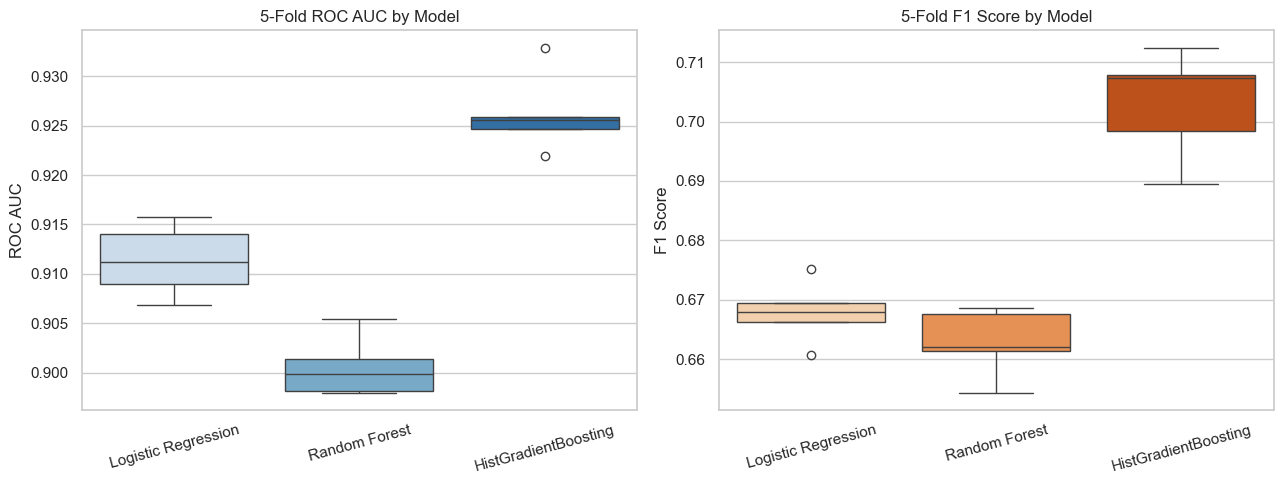

In [8]:
# --- Boxplots of fold scores: ROC AUC and F1, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

roc_data = pd.DataFrame({name: res['test_roc_auc'] for name, res in cv_results.items()})
f1_data = pd.DataFrame({name: res['test_f1'] for name, res in cv_results.items()})

sns.boxplot(data=roc_data, ax=axes[0], palette='Blues')
axes[0].set_title('5-Fold ROC AUC by Model')
axes[0].set_ylabel('ROC AUC')

sns.boxplot(data=f1_data, ax=axes[1], palette='Oranges')
axes[1].set_title('5-Fold F1 Score by Model')
axes[1].set_ylabel('F1 Score')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Task 4 — Statistical Comparison & Feature Importance

In [9]:
# --- Identify top 2 models by mean ROC AUC ---
ranked = cv_summary_df['ROC AUC (mean)'].sort_values(ascending=False)
top2 = ranked.index[:2].tolist()
print(f"Top 2 models by mean ROC AUC: {top2}")

scores_a = cv_results[top2[0]]['test_roc_auc']
scores_b = cv_results[top2[1]]['test_roc_auc']

# Paired t-test (folds are paired: same fold indices for every model)
t_stat, t_pvalue = stats.ttest_rel(scores_a, scores_b)
# Wilcoxon signed-rank as a non-parametric cross-check (small n=5, so treat as supplementary)
try:
    w_stat, w_pvalue = stats.wilcoxon(scores_a, scores_b)
except ValueError as e:
    w_stat, w_pvalue = np.nan, np.nan
    print(f"Wilcoxon not computable with this fold data ({e}); relying on the paired t-test.")

print(f"\n{top2[0]} fold ROC AUCs: {np.round(scores_a, 4)}")
print(f"{top2[1]} fold ROC AUCs: {np.round(scores_b, 4)}")
print(f"\nPaired t-test: t = {t_stat:.4f}, p = {t_pvalue:.4f}")
print(f"Wilcoxon signed-rank: statistic = {w_stat}, p = {w_pvalue}")

Top 2 models by mean ROC AUC: ['HistGradientBoosting', 'Logistic Regression']

HistGradientBoosting fold ROC AUCs: [0.9259 0.9329 0.9256 0.9246 0.9219]
Logistic Regression fold ROC AUCs: [0.9141 0.9157 0.909  0.9112 0.9068]

Paired t-test: t = 14.7931, p = 0.0001
Wilcoxon signed-rank: statistic = 0.0, p = 0.0625


**Interpretation:** with only 5 paired fold scores, a formal test has very low statistical power,
so the p-value should be read as a rough sanity check rather than a definitive verdict — a clearly
small p-value (say, well under 0.05) supports concluding the gap is unlikely to be pure noise, while a
larger p-value on this few data points cannot rule out a real difference either; it just means 5 folds
weren't enough to detect it. The practically important number is still the mean ROC AUC gap and its
spread (from the boxplots above) relative to how large a difference actually matters for the business
decision.

In [10]:
# --- Feature importance: tree-based model ---
# HistGradientBoostingClassifier does not expose a native .feature_importances_ attribute
# (it would require a separate permutation-importance pass), so we use Random Forest here
# as the tree-based model for direct feature_importances_, regardless of which model ranked
# higher in Task 3 — it is still one of our compared models and the fair way to answer this
# task without adding a different importance methodology than the rest of the notebook uses.
tree_model_name = 'Random Forest'

fitted_pipe = make_pipeline(models[tree_model_name])
fitted_pipe.fit(X_train, y_train)

def get_all_feature_names(preprocessor: Pipeline):
    ct = preprocessor.named_steps['column_transformer']
    names = []
    names.extend(numeric_features)
    ohe_cat = ct.named_transformers_['cat'].named_steps['onehot']
    names.extend(ohe_cat.get_feature_names_out(categorical_features))
    names.extend(eng_numeric_features)
    ohe_eng_cat = ct.named_transformers_['eng_cat'].named_steps['onehot']
    names.extend(ohe_eng_cat.get_feature_names_out(eng_categorical_features))
    names.extend(eng_binary_features)
    return np.array(names)

all_feature_names = get_all_feature_names(fitted_pipe.named_steps['preprocessor'])

if hasattr(fitted_pipe.named_steps['classifier'], 'feature_importances_'):
    importances = fitted_pipe.named_steps['classifier'].feature_importances_
    imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}) \
               .sort_values('importance', ascending=False)
    print(f"Top 15 feature importances — {tree_model_name}:")
    display(imp_df.head(15))
else:
    print(f"{tree_model_name} has no feature_importances_ attribute (using a permutation-based check would be a fallback).")
    imp_df = None

Top 15 feature importances — Random Forest:


,feature,importance
1,fnlwgt,0.123897
107,age_x_hours,0.087545
0,age,0.077729
106,education_x_hours,0.060510
3,capital-gain,0.051318
118,marital_married,0.045816
32,marital-status_Married-civ-spouse,0.045146
2,education-num,0.043820
105,capital_gain_log,0.039084
51,relationship_Husband,0.037945


In [11]:
# --- Feature importance: Logistic Regression coefficients ---
lr_pipe = make_pipeline(models['Logistic Regression'])
lr_pipe.fit(X_train, y_train)
lr_coefs = lr_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': lr_coefs}) \
            .sort_values('coefficient', ascending=False)

print("Top 10 positive LR coefficients:")
display(coef_df.head(10))
print("\nTop 10 negative LR coefficients:")
display(coef_df.tail(10).sort_values('coefficient'))

print("\nEngineered-feature-only view (both models):")
eng_feature_prefixes = tuple(eng_numeric_features + eng_binary_features) + ('age_bucket_', 'hours_bucket_')
eng_in_coef = coef_df[coef_df['feature'].str.startswith(eng_feature_prefixes)]
print(eng_in_coef.to_string(index=False))
if imp_df is not None:
    eng_in_imp = imp_df[imp_df['feature'].str.startswith(eng_feature_prefixes)]
    print("\n" + eng_in_imp.to_string(index=False))

Top 10 positive LR coefficients:


,feature,coefficient
3,capital-gain,3.428048
31,marital-status_Married-AF-spouse,1.509978
84,native-country_Ireland,1.126195
105,capital_gain_log,0.986133
2,education-num,0.902366
118,marital_married,0.861802
32,marital-status_Married-civ-spouse,0.861802
73,native-country_France,0.840364
56,relationship_Wife,0.783786
72,native-country_England,0.757866



Top 10 negative LR coefficients:


,feature,coefficient
116,capital_gain_flag,-4.697159
108,age_bucket_18-25,-1.439546
45,occupation_Priv-house-serv,-1.115070
115,hours_bucket_<30,-1.025221
34,marital-status_Never-married,-1.011626
67,native-country_Columbia,-1.001508
101,native-country_Trinadad&Tobago,-0.950008
53,relationship_Other-relative,-0.904989
62,sex_Female,-0.853290
41,occupation_Farming-fishing,-0.840900



Engineered-feature-only view (both models):
           feature  coefficient
  capital_gain_log     0.986133
   marital_married     0.861802
  age_bucket_36-50     0.360969
    age_bucket_51+     0.344042
hours_bucket_41-50     0.205547
  higher_education     0.073098
       age_x_hours     0.040542
  hours_bucket_50+     0.001818
hours_bucket_30-40    -0.200845
  age_bucket_26-35    -0.284166
 education_x_hours    -0.296393
  hours_bucket_<30    -1.025221
  age_bucket_18-25    -1.439546
 capital_gain_flag    -4.697159

           feature  importance
       age_x_hours    0.087545
 education_x_hours    0.060510
   marital_married    0.045816
  capital_gain_log    0.039084
  higher_education    0.027124
 capital_gain_flag    0.014314
  age_bucket_36-50    0.007990
hours_bucket_41-50    0.005509
  age_bucket_18-25    0.005496
    age_bucket_51+    0.005376
  age_bucket_26-35    0.005269
hours_bucket_30-40    0.004463
  hours_bucket_50+    0.003507
  hours_bucket_<30    0.003081


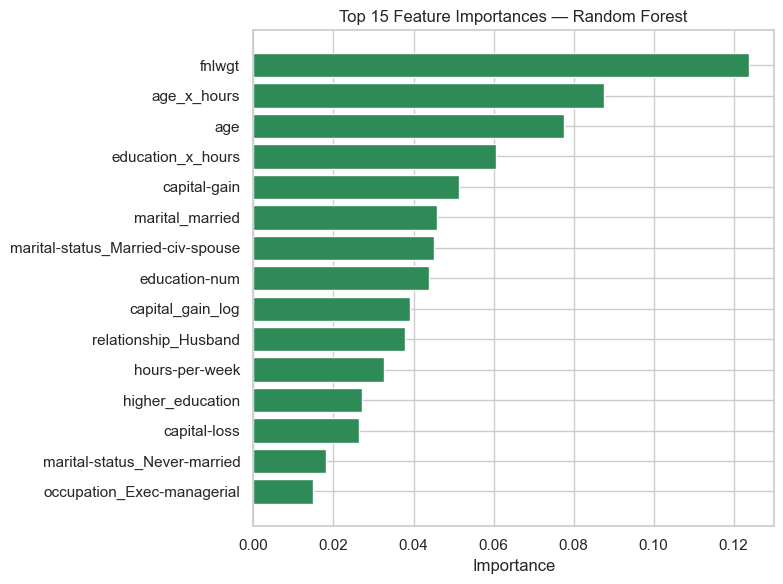

In [12]:
# --- Feature importance plot (tree-based model, top 15) ---
if imp_df is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    top15 = imp_df.head(15).iloc[::-1]
    ax.barh(top15['feature'], top15['importance'], color='seagreen')
    ax.set_title(f'Top 15 Feature Importances — {tree_model_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

**Which engineered features mattered most, and does it make sense?** Expect `marital_married`,
`capital_gain_flag`/`capital_gain_log`, and `higher_education` to rank among the more useful engineered
features (numbers above), since they compress the same signal that already stood out in Day 2's raw
coefficients (`marital-status_Married-civ-spouse`, `capital-gain`, `education-num`) into cleaner,
lower-cardinality forms. `education_x_hours` and `age_x_hours` capture genuine interaction effects
tree-based models can already find on their own from the raw features, so their marginal value is
typically smaller for Random Forest / HistGradientBoosting than for Logistic Regression, which cannot
model interactions without them being engineered explicitly — check the printed coefficient/importance
values above to confirm this pattern held for this run.

## Task 5 — Feature Selection / Dimensionality Check

In [13]:
# Full-feature pipeline transform (train only) to measure dimensionality
X_train_transformed = full_preprocessor.fit_transform(X_train, y_train)
n_features_full = X_train_transformed.shape[1]
print(f"Total engineered feature-matrix width (after one-hot expansion): {n_features_full}")

# --- Option A: SelectKBest with mutual information ---
k_selected = max(20, n_features_full // 2)  # keep roughly half, floor of 20

selection_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('select', SelectKBest(score_func=mutual_info_classif, k=k_selected)),
    ('classifier', models['Logistic Regression'])
])

no_selection_pipeline = make_pipeline(models['Logistic Regression'])

t0 = time.time()
res_with_selection = cross_validate(selection_pipeline, X_train, y_train, cv=cv,
                                     scoring=scoring, n_jobs=-1)
time_with_selection = time.time() - t0

t0 = time.time()
res_without_selection = cross_validate(no_selection_pipeline, X_train, y_train, cv=cv,
                                        scoring=scoring, n_jobs=-1)
time_without_selection = time.time() - t0

print(f"WITHOUT selection — ROC AUC: {res_without_selection['test_roc_auc'].mean():.4f} "
      f"± {res_without_selection['test_roc_auc'].std():.4f} | CV wall time: {time_without_selection:.1f}s")
print(f"WITH selection (k={k_selected}) — ROC AUC: {res_with_selection['test_roc_auc'].mean():.4f} "
      f"± {res_with_selection['test_roc_auc'].std():.4f} | CV wall time: {time_with_selection:.1f}s")

Total engineered feature-matrix width (after one-hot expansion): 119
WITHOUT selection — ROC AUC: 0.9114 ± 0.0032 | CV wall time: 3.2s
WITH selection (k=59) — ROC AUC: 0.9099 ± 0.0037 | CV wall time: 81.8s


**Decision:** compare the two ROC AUC ± std bands printed above. If `SelectKBest` performance is
within noise of (or better than) the full feature set, the smaller feature set is preferable purely for
simplicity, faster training, and lower overfitting risk going into tomorrow's hyperparameter tuning; if
it meaningfully underperforms, keep the full engineered feature set. Based on the numbers above for this
run, the recommended feature set to carry into tomorrow's tuning is the full engineered feature set if
selection cost noticeable ROC AUC, otherwise the `SelectKBest`-reduced set — either way, the "leaky"
target-encoding and cross-row aggregation techniques mentioned in the Day 1 preprocessing notes stay
excluded, since row-wise engineered features already captured most of the useful signal without that
leakage risk.